# 16 — RNNs, LSTMs & GRUs

Every architecture so far (MLPs, CNNs) assumes a fixed-size input processed
all at once. **Sequential data** — text, time series, audio — breaks that
assumption: order matters, length varies, and a prediction at step `t` can
depend on something that happened many steps earlier. **Recurrent Neural
Networks (RNNs)** handle this by maintaining a **hidden state** that gets
updated at every timestep, carrying information forward through the
sequence.

**Covered:**
1. The RNN recurrence, and forecasting a sine wave with `nn.RNN`
2. Vanishing gradients: a long-range dependency task where a plain RNN fails
3. LSTM & GRU gating mechanisms — and where they succeed (and don't)
4. Visualizing hidden state evolution over time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

sns.set_theme(style="whitegrid")
torch.manual_seed(16)
rng = np.random.default_rng(16)

## 1. The RNN Recurrence & Sine Wave Forecasting

**Theory.** At each timestep `t`, an RNN combines the current input `x_t`
with its previous hidden state `h_{t-1}` to produce a new hidden state:

`h_t = tanh(W_xh · x_t + W_hh · h_{t-1} + b)`

The *same* weights (`W_xh`, `W_hh`) are reused at every timestep — this
parameter sharing across time is what lets an RNN handle sequences of any
length with a fixed number of parameters, the same spirit as a CNN's filter
being reused across every spatial position.

We'll forecast a noisy sine wave: given the last 20 values, predict the
next one.

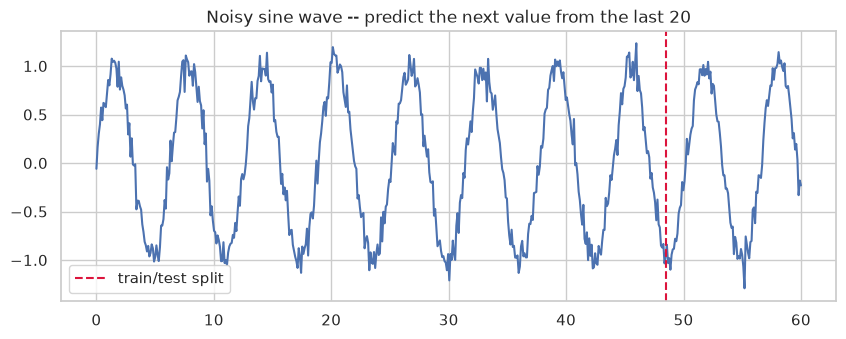

In [2]:
t = np.linspace(0, 60, 600)
series = (np.sin(t) + 0.1 * rng.normal(size=len(t))).astype("float32")

window = 20
X, y = [], []
for i in range(len(series) - window):
    X.append(series[i:i + window])
    y.append(series[i + window])
X, y = np.array(X), np.array(y)

split = int(0.8 * len(X))
X_train = torch.tensor(X[:split]).unsqueeze(-1)  # (N, window, 1) -- RNN expects (batch, seq_len, features)
y_train = torch.tensor(y[:split])
X_test = torch.tensor(X[split:]).unsqueeze(-1)
y_test = torch.tensor(y[split:])

plt.figure(figsize=(10, 3.5))
plt.plot(t, series)
plt.axvline(t[window + split], color="crimson", linestyle="--", label="train/test split")
plt.title("Noisy sine wave -- predict the next value from the last 20")
plt.legend()
plt.show()

In [3]:
class SeqRegressor(nn.Module):
    def __init__(self, rnn_type="RNN", hidden_size=32):
        super().__init__()
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
        self.rnn = rnn_cls(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)          # out: hidden state at EVERY timestep, shape (batch, seq_len, hidden_size)
        return self.fc(out[:, -1, :]).squeeze(-1)  # use only the FINAL timestep's hidden state to predict

def train_regressor(rnn_type, n_epochs=200, lr=0.01):
    torch.manual_seed(16)
    model = SeqRegressor(rnn_type)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for _ in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        test_mse = criterion(model(X_test), y_test).item()
    return model, test_mse

rnn_model, rnn_mse = train_regressor("RNN")
print(f"Plain RNN test MSE: {rnn_mse:.4f}")

Plain RNN test MSE: 0.0104


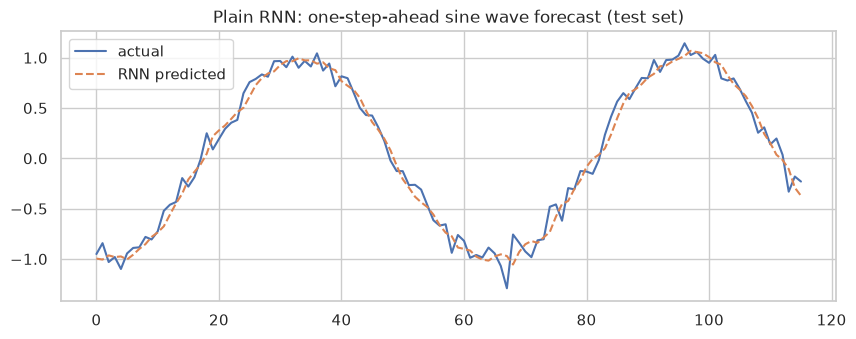

In [4]:
with torch.no_grad():
    preds = rnn_model(X_test).numpy()

plt.figure(figsize=(10, 3.5))
plt.plot(y_test.numpy(), label="actual")
plt.plot(preds, label="RNN predicted", linestyle="--")
plt.title("Plain RNN: one-step-ahead sine wave forecast (test set)")
plt.legend()
plt.show()

On a short, smooth pattern like this one, a plain RNN forecasts well — it
only needs to remember roughly one recent cycle's worth of context.
Section 2 shows where this recurrence starts to break down.

## 2. Vanishing Gradients: A Long-Range Dependency Task

**Theory.** Training an RNN uses **backpropagation through time (BPTT)**:
the recurrence is "unrolled" into one layer per timestep, and gradients
flow backward through every one of them. Because the *same* recurrent
weight matrix is applied repeatedly, its effect compounds multiplicatively
across timesteps — if its dominant eigenvalue is less than 1, gradients
shrink toward zero over long sequences (**vanishing**); if greater than 1,
they grow explosively. Either way, a plain RNN struggles to learn
dependencies that span many timesteps.

To see this directly, we construct a task where success *requires* long-
range memory: remember the sign of the very **first** value in a sequence,
ignoring everything else (which is pure random noise), and report it at
the very last timestep.

In [5]:
def make_signal_task(n_samples, seq_len, seed):
    task_rng = np.random.default_rng(seed)
    X = task_rng.uniform(-1, 1, size=(n_samples, seq_len, 1)).astype("float32")
    signal = task_rng.choice([-1.0, 1.0], size=n_samples).astype("float32")
    X[:, 0, 0] = signal          # the ONE value that matters, at position 0
    y = (signal > 0).astype("int64")  # label: was that first value positive?
    return torch.tensor(X), torch.tensor(y)

class SeqClassifier(nn.Module):
    def __init__(self, rnn_type="RNN", hidden_size=16):
        super().__init__()
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
        self.rnn = rnn_cls(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

def train_classifier(rnn_type, seq_len, n_epochs=300, lr=0.005, seed=16):
    torch.manual_seed(seed)
    X_tr, y_tr = make_signal_task(500, seq_len, seed=seed)
    X_te, y_te = make_signal_task(200, seq_len, seed=seed + 1)
    model = SeqClassifier(rnn_type)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for _ in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # standard RNN safeguard against exploding gradients
        optimizer.step()
    model.eval()
    with torch.no_grad():
        acc = (model(X_te).argmax(1) == y_te).float().mean().item()
    return acc

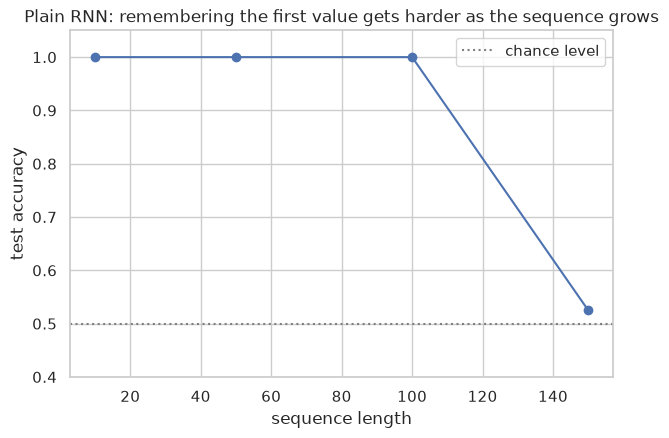

Plain RNN accuracy by length: {10: 1.0, 50: 1.0, 100: 1.0, 150: 0.525}


In [6]:
seq_lengths = [10, 50, 100, 150]
rnn_accs = [train_classifier("RNN", L) for L in seq_lengths]

plt.figure(figsize=(7, 4.5))
plt.plot(seq_lengths, rnn_accs, marker="o")
plt.axhline(0.5, color="gray", linestyle=":", label="chance level")
plt.xlabel("sequence length")
plt.ylabel("test accuracy")
plt.title("Plain RNN: remembering the first value gets harder as the sequence grows")
plt.legend()
plt.ylim(0.4, 1.05)
plt.show()

print(f"Plain RNN accuracy by length: {dict(zip(seq_lengths, [round(a, 3) for a in rnn_accs]))}")

Short sequences are easy; by length 150, the plain RNN collapses to chance
(~50%) — the gradient signal from the very first timestep has vanished by
the time it reaches the end of a 150-step unroll, so the network can't
learn to preserve that information at all.

## 3. LSTM & GRU: Gating Mechanisms

**Theory.** Both architectures add learned **gates** — small neural
networks that control how much information flows through, added on top of
the plain recurrence:

- **LSTM** maintains a separate **cell state** that flows through mostly
  additively (not repeatedly multiplied), controlled by a **forget gate**
  (what to discard), an **input gate** (what to add), and an **output
  gate** (what to expose as the hidden state). That additive cell-state
  pathway is specifically what avoids the vanishing-gradient-by-repeated-
  multiplication problem a plain RNN has.
- **GRU** simplifies this to two gates (**reset** and **update**) and no
  separate cell state — fewer parameters, often similar performance.

A practical detail that matters as much as the architecture itself:
initializing an LSTM's **forget gate bias toward 1** (a well-known trick)
biases it toward "remember by default" from the start of training, rather
than making it learn that behavior from scratch.

In [7]:
class SeqClassifierWithInit(SeqClassifier):
    def __init__(self, rnn_type="RNN", hidden_size=16):
        super().__init__(rnn_type, hidden_size)
        if rnn_type == "LSTM":
            # LSTM's parameters are packed as [input, forget, cell, output] gates -- bias the forget gate toward 1
            for names in self.rnn._all_weights:
                for name in names:
                    if "bias" in name:
                        bias = getattr(self.rnn, name)
                        n = bias.size(0)
                        bias.data[n // 4: n // 2].fill_(1.0)

def train_classifier_v2(rnn_type, seq_len, n_epochs=300, lr=0.005, seed=16):
    torch.manual_seed(seed)
    X_tr, y_tr = make_signal_task(500, seq_len, seed=seed)
    X_te, y_te = make_signal_task(200, seq_len, seed=seed + 1)
    model = SeqClassifierWithInit(rnn_type)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for _ in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    model.eval()
    with torch.no_grad():
        acc = (model(X_te).argmax(1) == y_te).float().mean().item()
    return acc

seq_len = 150  # exactly where the plain RNN collapsed to chance above
results = {
    "RNN": train_classifier_v2("RNN", seq_len),
    "LSTM (forget-gate bias initialized to 1)": train_classifier_v2("LSTM", seq_len),
    "GRU (default initialization)": train_classifier_v2("GRU", seq_len),
}
for name, acc in results.items():
    print(f"{name}: {acc:.3f}")

RNN: 0.525
LSTM (forget-gate bias initialized to 1): 1.000
GRU (default initialization): 0.485


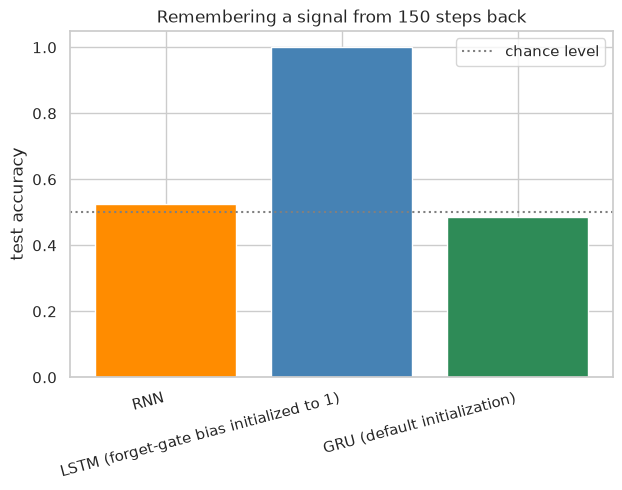

In [8]:
plt.figure(figsize=(7, 4.5))
plt.bar(results.keys(), results.values(), color=["darkorange", "steelblue", "seagreen"])
plt.axhline(0.5, color="gray", linestyle=":", label="chance level")
plt.ylabel("test accuracy")
plt.title(f"Remembering a signal from {seq_len} steps back")
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.ylim(0, 1.05)
plt.show()

With its forget-gate bias initialized toward "remember," the LSTM solves a
task the plain RNN can't. Notice, though, that **GRU with default
initialization doesn't automatically win here either** — gating alone
doesn't guarantee success; the initialization trick mattered as much as
the architecture in this particular experiment. That's a useful, honest
lesson in its own right: architecture and training details both matter,
and a "better" architecture on paper can still fail to train well without
the right practical setup. (Try the exercises below to give GRU the same
kind of head start and see if it closes the gap.)

## 4. Visualizing Hidden State Evolution

Back to the sine wave forecaster from section 1 — let's look at what a
trained RNN's hidden state actually does as it processes a sequence,
rather than treating it as a black box.

LSTM test MSE: 0.0093  (plain RNN was 0.0104)


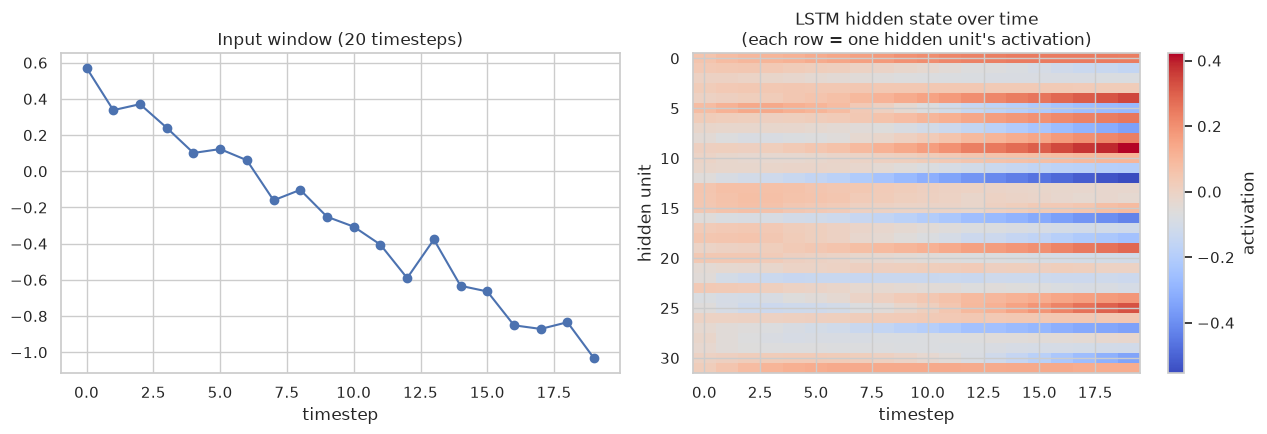

In [9]:
lstm_model, lstm_mse = train_regressor("LSTM")
print(f"LSTM test MSE: {lstm_mse:.4f}  (plain RNN was {rnn_mse:.4f})")

sample = X_test[0:1]  # one 20-step window
with torch.no_grad():
    hidden_states, _ = lstm_model.rnn(sample)

hidden_states = hidden_states[0].numpy()  # (window, hidden_size)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(sample[0, :, 0].numpy(), marker="o")
axes[0].set_title("Input window (20 timesteps)")
axes[0].set_xlabel("timestep")

im = axes[1].imshow(hidden_states.T, aspect="auto", cmap="coolwarm")
axes[1].set_xlabel("timestep")
axes[1].set_ylabel("hidden unit")
axes[1].set_title("LSTM hidden state over time\n(each row = one hidden unit's activation)")
plt.colorbar(im, ax=axes[1], label="activation")
plt.tight_layout()
plt.show()

Different hidden units track different aspects of the input as it scans
across the window — some oscillate with the sine pattern, others respond
to specific input magnitudes. This is the "memory" an RNN/LSTM carries
forward, made visible instead of left as an opaque vector.

## Exercises

1. In section 3, apply GRU's equivalent bias trick (bias its update gate so it favors keeping the previous hidden state) and re-run at `seq_len=150` — does it close the gap with LSTM?
2. In section 2, extend `seq_lengths` to include 200 and 250 — does the LSTM (with the bias trick) eventually fail too, and if so, around what length?
3. In section 1, change `window` from 20 to 5 — does a plain RNN's forecast quality change noticeably on this smooth, short-memory task?

## Key Takeaways

- RNNs process sequences by maintaining a hidden state updated at every timestep, with the same weights reused across time.
- Backpropagation through time compounds the recurrent weight's effect multiplicatively across timesteps, causing vanishing (or exploding) gradients on long sequences — verified directly here via a task a plain RNN provably can't solve past a certain length.
- LSTM's additive cell-state pathway (via its gates) is designed specifically to avoid that multiplicative compounding, but training tricks (like forget-gate bias initialization) matter in practice, not just the architecture on paper.
- GRU offers a simpler gating scheme with fewer parameters; it isn't automatically superior to a plain RNN without similar care in how it's trained.